<a href="https://colab.research.google.com/github/miacachion/Final-Project/blob/main/milestone3_mia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Clone in Fork**

In [ ]:
! git clone https://github.com/miacachion/Final-Project.git

Cloning into 'Final-Project'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 54 (delta 19), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 776.80 KiB | 10.09 MiB/s, done.
Resolving deltas: 100% (19/19), done.


**Cleaning and Wrangling**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report

In [51]:
df = pd.read_csv('/content/Final-Project/data/CVD Dataset.csv')
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,CVD Risk Level,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,INTERMEDIARY,171.0,0.504,125.0,79.0,Elevated,140.0,17.93
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,HIGH,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,INTERMEDIARY,183.0,0.583,104.0,77.0,Normal,0.0,12.64
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,INTERMEDIARY,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,INTERMEDIARY,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88


In [52]:
print("Smoking Status uniques:", df['Smoking Status'].dropna().unique())
print("Physical Activity Level uniques:", df['Physical Activity Level'].dropna().unique())
print("Blood Pressure Category uniques:", df['Blood Pressure Category'].dropna().unique())

Smoking Status uniques: ['N' 'Y']
Physical Activity Level uniques: ['Low' 'High' 'Moderate']
Blood Pressure Category uniques: ['Elevated' 'Hypertension Stage 1' 'Normal' 'Hypertension Stage 2']


In [53]:
# Map blood pressure categories
bp_map = {
    'Normal': 0,
    'Elevated': 1,
    'Hypertension Stage 1': 2,
    'Hypertension Stage 2': 3,
}
df['BP_Category_Label'] = df['Blood Pressure Category'].map(bp_map)

df['abnormal_bp'] = np.where(df['BP_Category_Label'] >= 2, 1, 0)

df[['Blood Pressure Category','BP_Category_Label','abnormal_bp']].value_counts().sort_index()

,,,count
Blood Pressure Category,BP_Category_Label,abnormal_bp,
Elevated,1,0,100
Hypertension Stage 1,2,1,497
Hypertension Stage 2,3,1,632
Normal,0,0,300


In [54]:
df2 = df[['Smoking Status','Physical Activity Level','BP_Category_Label','abnormal_bp']].copy()

# Standardize
df2['Smoking Status'] = df2['Smoking Status'].str.strip()
df2['Physical Activity Level'] = df2['Physical Activity Level'].str.strip()

df2['smoking_clean'] = df2['Smoking Status'].map({'N': 'Non-smoker', 'Y': 'Smoker'})
df2['activity_clean'] = df2['Physical Activity Level'].str.lower()

activity_order = {'low': 0, 'moderate': 1, 'high': 2}
df2['activity_ord'] = df2['activity_clean'].map(activity_order)

print(df2['smoking_clean'].value_counts())
print(df2['activity_clean'].value_counts())

smoking_clean
Smoker        789
Non-smoker    740
Name: count, dtype: int64
activity_clean
high        521
moderate    512
low         496
Name: count, dtype: int64


**EDA**

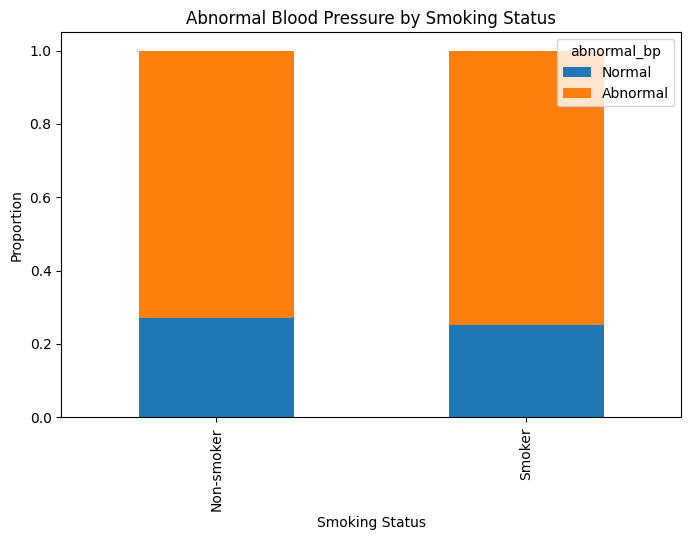

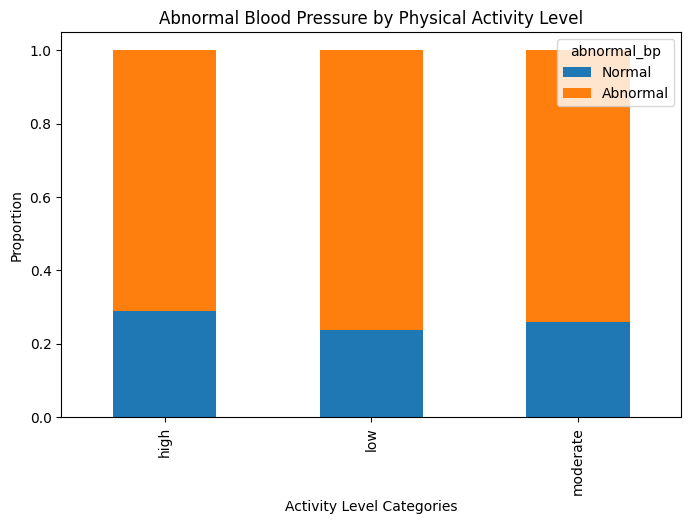

In [55]:
# Stacked proportions
ct = pd.crosstab(df2['smoking_clean'], df2['abnormal_bp'], normalize='index')
ct = ct.rename(columns={0: "Normal", 1: "Abnormal"})
ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Abnormal Blood Pressure by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Proportion')
plt.legend(title='abnormal_bp', loc='upper right')
plt.show()

ct = pd.crosstab(df2['activity_clean'], df2['abnormal_bp'], normalize='index')
ct = ct.rename(columns={0: "Normal", 1: "Abnormal"})
ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Abnormal Blood Pressure by Physical Activity Level')
plt.xlabel('Activity Level Categories')
plt.ylabel('Proportion')
plt.legend(title='abnormal_bp', loc='upper right')
plt.show()

**Modeling**

In [56]:
X = df2[['smoking_clean','activity_ord']]
y = df2['abnormal_bp']

# One-hot encode
X_encoded = pd.get_dummies(X, columns=['smoking_clean'], drop_first=True)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

Decision Tree Confusion Matrix:
[[ 41  39]
 [114 112]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.51      0.35        80
           1       0.74      0.50      0.59       226

    accuracy                           0.50       306
   macro avg       0.50      0.50      0.47       306
weighted avg       0.62      0.50      0.53       306



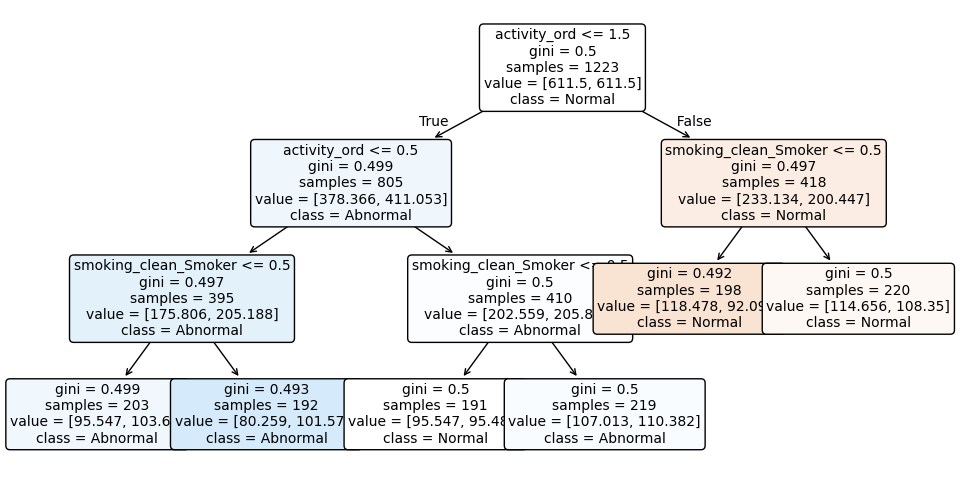

                feature  importance
0          activity_ord    0.747768
1  smoking_clean_Smoker    0.252232


In [58]:
# Decision tree model
dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=X_encoded.columns, class_names=['Normal','Abnormal'],
          filled=True, rounded=True, fontsize=10)
plt.show()

fi = pd.DataFrame({'feature': X_encoded.columns, 'importance': dt.feature_importances_}).sort_values('importance', ascending=False)
print(fi)